## Step-1 : Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage import data,color,io,img_as_ubyte
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, square ,footprint_rectangle

## Step-2 : Load the biomedical images
For this example, let&#39;s use sample images from the skimage library. Alternatively, you can
upload your biomedical images

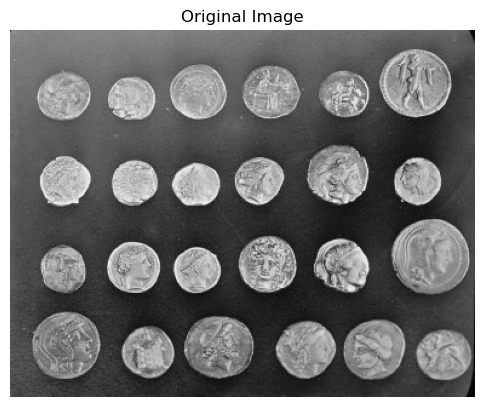

In [2]:
# Load a sample biomedical image
image = data.coins() # Replace with your biomedical image

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image,cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [3]:
img = data.camera()
print(f"Shape: {img.shape}")
print(f"Dtype: {img.dtype}")
print(f"Range: {img.min()} to {img.max()}")

Shape: (512, 512)
Dtype: uint8
Range: 0 to 255


## Step-3 : Preprocess the image
Apply preprocessing techniques such as resizing, denoising, and contrast adjustment.

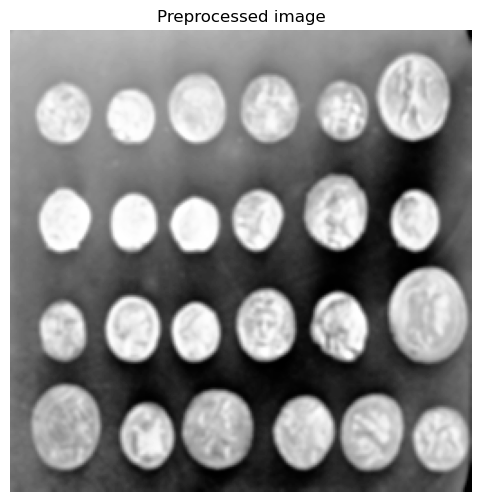

In [4]:
# Resize the image
resized_image = cv2.resize(image, (256, 256))
# Denoise the image
denoised_image = cv2.GaussianBlur(resized_image, (5, 5), 0)
# Adjust the contrast (if necessary)
# Convert to uint8 and ensure single channel
if denoised_image.dtype != np.uint8:
    denoised_image = img_as_ubyte(denoised_image)

# Apply histogram equalization
contrast_image = cv2.equalizeHist(denoised_image)


# Display
plt.figure(figsize=(6,6))
plt.imshow(contrast_image,cmap='gray')
plt.title("Preprocessed image")
plt.axis('off')
plt.show()

## Step-4 : Image Segmentation
Perform image segmentation to identify regions of interest.

Otsu threshold value: 128
Number of regions found: 18


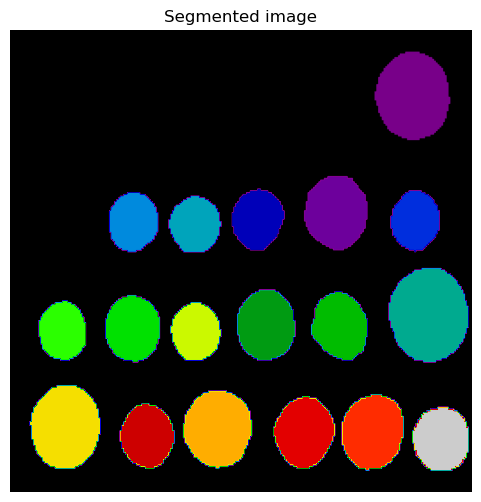

In [5]:
# Apply thresholding
thresh = threshold_otsu(contrast_image)
print(f"Otsu threshold value: {thresh}")

# Create binary image FIRST, then apply closing
binary_image = contrast_image > thresh

# Apply morphological closing to fill holes
# Option 1: Using the new footprint_rectangle (recommended)
footprint = footprint_rectangle((3, 3))
binary_image = closing(binary_image, footprint)

# Remove artifacts connected to image border
cleared = clear_border(binary_image)
# Label image regions
label_image = label(cleared)
print(f"Number of regions found: {label_image.max()}")

# Display the segmented image
plt.figure(figsize=(6, 6))
plt.imshow(label_image, cmap='nipy_spectral')
plt.title('Segmented image')
plt.axis('off')
plt.show()

## Step-5 : Feature Extraction
Extract features from the segmented regions


Region 1 : Area = 1581.0, Perimeter = 147.53910524340094
Region 2 : Area = 1116.0, Perimeter = 122.8111831820431
Region 3 : Area = 739.0, Perimeter = 99.74011537017762
Region 4 : Area = 698.0, Perimeter = 96.91168824543142
Region 5 : Area = 713.0, Perimeter = 97.25483399593904
Region 6 : Area = 690.0, Perimeter = 96.66904755831213
Region 7 : Area = 1805.0, Perimeter = 156.95331880577402
Region 8 : Area = 1003.0, Perimeter = 115.74011537017762
Region 9 : Area = 889.0, Perimeter = 111.1543289325507
Region 10 : Area = 880.0, Perimeter = 108.91168824543142
Region 11 : Area = 678.0, Perimeter = 95.25483399593904
Region 12 : Area = 691.0, Perimeter = 96.08326112068522
Region 13 : Area = 1414.0, Perimeter = 138.46803743153546
Region 14 : Area = 1269.0, Perimeter = 132.22539674441617
Region 15 : Area = 1135.0, Perimeter = 124.5685424949238
Region 16 : Area = 1001.0, Perimeter = 117.05382386916236
Region 17 : Area = 811.0, Perimeter = 105.1543289325507
Region 18 : Area = 883.0, Perimeter = 108.

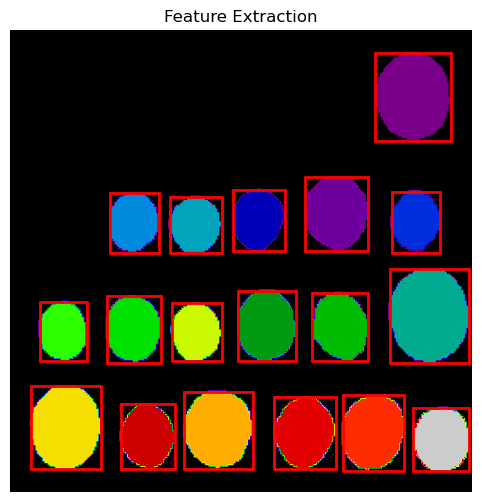

In [6]:
# Extract region properties
regions = regionprops(label_image)

#Dsiplay the properties of the regions
for region in regions :
    #Take the region with large enough area
    if region.area > 100 :
        print(f'Region {region.label} : Area = {region.area}, Perimeter = {region.perimeter}')

#Disply the regions
plt.figure(figsize=(8,6))
plt.imshow(label_image,cmap='nipy_spectral')

for region in regions:
    if region.area >= 100:
    # Draw rectangle around segmented regions
        minr, minc, maxr, maxc = region.bbox
        rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr,
            fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)

plt.title('Feature Extraction')
plt.axis('off')
plt.show()

## Step-6 : Detection
Detect specific features or regions based on th extracted features


Detected Region : 1 : Area = 1581.0, perimeter = 147.53910524340094
Detected Region : 2 : Area = 1116.0, perimeter = 122.8111831820431
Detected Region : 3 : Area = 739.0, perimeter = 99.74011537017762
Detected Region : 4 : Area = 698.0, perimeter = 96.91168824543142
Detected Region : 5 : Area = 713.0, perimeter = 97.25483399593904
Detected Region : 6 : Area = 690.0, perimeter = 96.66904755831213
Detected Region : 7 : Area = 1805.0, perimeter = 156.95331880577402
Detected Region : 8 : Area = 1003.0, perimeter = 115.74011537017762
Detected Region : 9 : Area = 889.0, perimeter = 111.1543289325507
Detected Region : 10 : Area = 880.0, perimeter = 108.91168824543142
Detected Region : 11 : Area = 678.0, perimeter = 95.25483399593904
Detected Region : 12 : Area = 691.0, perimeter = 96.08326112068522
Detected Region : 13 : Area = 1414.0, perimeter = 138.46803743153546
Detected Region : 14 : Area = 1269.0, perimeter = 132.22539674441617
Detected Region : 15 : Area = 1135.0, perimeter = 124.56854

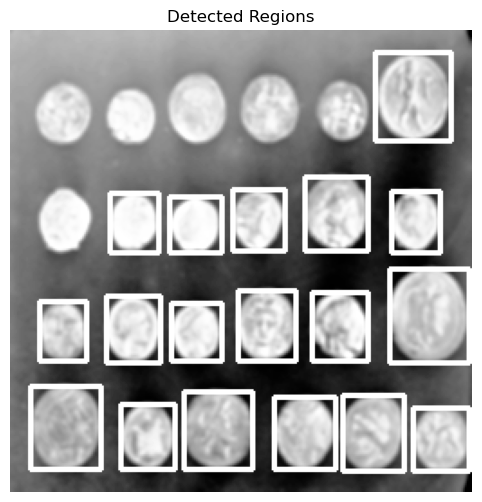

In [7]:
# Detect specific features(e.g. regions with area>200)
for region in regions : 
    if region.area > 200 :
        print(f'Detected Region : {region.label} : Area = {region.area}, perimeter = {region.perimeter}')
        minr,minc,maxr,maxc = region.bbox
        cv2.rectangle(contrast_image, 
                     (minc, minr),      # Top-left corner (x, y)
                     (maxc, maxr),      # Bottom-right corner (x, y)
                     (255, 0, 0),       # Blue color in BGR format
                     2)                 # Thickness

#Display the detected regions
plt.figure(figsize=(8,6))
plt.imshow(contrast_image,cmap='gray')
plt.title("Detected Regions")
plt.axis('off')
plt.show()